"""
Phase 3: Physics-Informed Neural Networks (PINNs)
==================================================
pip install torch numpy matplotlib

Two examples of increasing difficulty:
  1. 1D Poisson equation  –u''(x) = sin(πx)  [has exact solution → easy to validate]
  2. 1D Burgers equation   u_t + u·u_x = ν·u_xx  [nonlinear, canonical PINN benchmark]

Both follow the same recipe:
  ① Parameterise u(x) or u(x,t) with an MLP
  ② Automatic-differentiation gives PDE residuals
  ③ Total loss = λ_pde·L_pde + λ_bc·L_bc + λ_ic·L_ic
  ④ Minimise with Adam then refine with L-BFGS
"""

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

Device: cpu



In [2]:
# ─── Shared utility ────────────────────────────────────────────

def grad(out, inp, order=1, create_graph=True):
    """∂^order out / ∂inp^order, summing over batch."""
    g = out
    for _ in range(order):
        g = torch.autograd.grad(
            g, inp,
            grad_outputs=torch.ones_like(g),
            create_graph=create_graph,
            retain_graph=True
        )[0]
    return g


class PINN(nn.Module):
    """
    Fully-connected network with Tanh activations.
    'in_dim' includes all continuous inputs (x, or x+t).
    Using Tanh (not ReLU) is critical: PINNs need smooth,
    infinitely-differentiable activations.
    """
    def __init__(self, in_dim=1, hidden=64, depth=5):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 2):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)

        # Xavier initialisation: keeps gradients well-scaled for deep Tanh nets
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, *inputs):
        return self.net(torch.cat(inputs, dim=-1))


def train(model, loss_fn, lr=1e-3, adam_iters=5000, lbfgs_iters=500):
    """Two-phase training: Adam warm-up then L-BFGS polish."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for step in range(adam_iters):
        opt.zero_grad()
        loss, parts = loss_fn()
        loss.backward()
        opt.step()
        if step % 1000 == 0:
            msg = " | ".join(f"{k}: {v:.2e}" for k, v in parts.items())
            print(f"  Adam {step:5d} | {msg}")

    # L-BFGS: second-order method, dramatically reduces residual
    lbfgs = torch.optim.LBFGS(
        model.parameters(), lr=1.0,
        max_iter=lbfgs_iters, history_size=50,
        line_search_fn="strong_wolfe"
    )

    def closure():
        lbfgs.zero_grad()
        loss, _ = loss_fn()
        loss.backward()
        return loss

    lbfgs.step(closure)
    loss_final, _ = loss_fn()
    print(f"  L-BFGS done | final loss: {loss_final.item():.2e}\n")



In [3]:
# ═══════════════════════════════════════════════════════════════
# EXAMPLE 1: 1D Poisson equation
# −u''(x) = f(x),  x ∈ [0,1]
# f(x)    = sin(πx)
# BCs     : u(0) = u(1) = 0
# Exact   : u(x) = sin(πx) / π²
# ═══════════════════════════════════════════════════════════════

print("=" * 60)
print("EXAMPLE 1: 1D Poisson  –u'' = sin(πx)")
print("=" * 60)

pinn1 = PINN(in_dim=1, hidden=64, depth=4).to(device)

N_col = 2000
N_bc  = 2

x_col = torch.rand(N_col, 1, requires_grad=True).to(device)
x_bc  = torch.tensor([[0.0], [1.0]]).to(device)
u_bc  = torch.zeros(2, 1).to(device)


def poisson_loss():
    u    = pinn1(x_col)
    u_xx = grad(u, x_col, order=2)
    f    = torch.sin(torch.pi * x_col)

    L_pde = (-u_xx - f).pow(2).mean()
    L_bc  = (pinn1(x_bc) - u_bc).pow(2).mean()

    total = L_pde + 100.0 * L_bc          # BC weight: enforce BCs harder
    return total, {"PDE": L_pde.item(), "BC": L_bc.item()}


train(pinn1, poisson_loss, adam_iters=5000, lbfgs_iters=300)

x_test = torch.linspace(0, 1, 300).unsqueeze(1).to(device)
with torch.no_grad():
    u_pred = pinn1(x_test).cpu()
u_exact = torch.sin(torch.pi * x_test.cpu()) / (torch.pi ** 2)
rel_l2 = ((u_pred - u_exact).pow(2).mean().sqrt()
          / u_exact.pow(2).mean().sqrt()).item()
print(f"  Relative L2 error: {rel_l2:.4f}  (target < 0.005)\n")

EXAMPLE 1: 1D Poisson  –u'' = sin(πx)
  Adam     0 | PDE: 5.80e-01 | BC: 1.29e-02
  Adam  1000 | PDE: 4.81e-03 | BC: 2.38e-09
  Adam  2000 | PDE: 8.45e-04 | BC: 3.95e-07
  Adam  3000 | PDE: 2.47e-04 | BC: 9.40e-10
  Adam  4000 | PDE: 1.76e-04 | BC: 1.07e-09
  L-BFGS done | final loss: 2.52e-06

  Relative L2 error: 0.0001  (target < 0.005)



EXAMPLE 2: 1D Burgers  u_t + u·u_x = ν·u_xx
  Adam     0 | PDE: 9.89e-03 | IC: 3.82e-01 | BC: 7.80e-02
  Adam  1000 | PDE: 1.90e-01 | IC: 3.83e-03 | BC: 1.22e-04
  Adam  2000 | PDE: 1.28e-01 | IC: 3.31e-03 | BC: 6.98e-04
  Adam  3000 | PDE: 3.60e-02 | IC: 5.81e-04 | BC: 3.45e-05
  Adam  4000 | PDE: 1.29e-02 | IC: 1.47e-04 | BC: 8.15e-06
  Adam  5000 | PDE: 6.80e-03 | IC: 1.04e-04 | BC: 9.45e-06
  Adam  6000 | PDE: 6.97e-03 | IC: 1.23e-04 | BC: 2.06e-05
  Adam  7000 | PDE: 1.42e-03 | IC: 7.82e-05 | BC: 2.00e-04
  Adam  8000 | PDE: 1.79e-01 | IC: 3.38e-03 | BC: 9.86e-06
  Adam  9000 | PDE: 2.92e-02 | IC: 5.38e-04 | BC: 1.28e-05
  L-BFGS done | final loss: 2.09e-04

Plots saved → phase3_pinn_burgers.png
Plot saved → phase3_pinn_poisson.png


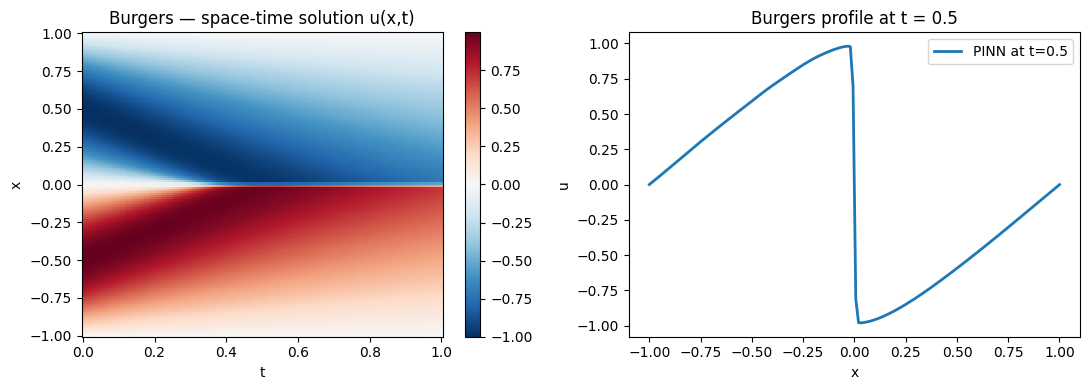

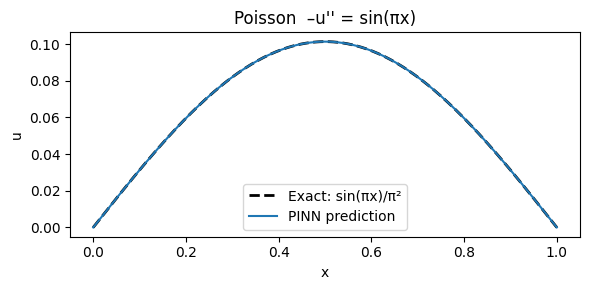

In [4]:
# ═══════════════════════════════════════════════════════════════
# EXAMPLE 2: 1D viscous Burgers equation
# u_t + u·u_x = ν·u_xx,   (x,t) ∈ [-1,1] × [0,1]
# IC:  u(x,0) = −sin(πx)
# BCs: u(−1,t) = u(1,t) = 0
# ν   = 0.01/π  (standard test case from Raissi et al. 2019)
#
# There's no closed-form solution, but we compare against a
# high-resolution finite-difference reference at t=0.5.
# ═══════════════════════════════════════════════════════════════

print("=" * 60)
print("EXAMPLE 2: 1D Burgers  u_t + u·u_x = ν·u_xx")
print("=" * 60)

nu = 0.01 / torch.pi

pinn2 = PINN(in_dim=2, hidden=100, depth=6).to(device)

# Collocation points sampled randomly in (x,t)
N_pde = 10_000
N_ic  = 200
N_bc  = 200

x_pde = (2 * torch.rand(N_pde, 1) - 1).requires_grad_(True).to(device)
t_pde = (    torch.rand(N_pde, 1)    ).requires_grad_(True).to(device)

x_ic  = (2 * torch.rand(N_ic, 1) - 1).to(device)
t_ic  = torch.zeros(N_ic, 1).to(device)
u_ic  = -torch.sin(torch.pi * x_ic)             # IC: u(x,0) = −sin(πx)

x_bc_left  = -torch.ones(N_bc, 1).to(device)
x_bc_right =  torch.ones(N_bc, 1).to(device)
t_bc       = torch.rand(N_bc, 1).to(device)
u_zero     = torch.zeros(N_bc, 1).to(device)


def burgers_loss():
    u     = pinn2(x_pde, t_pde)
    u_t   = torch.autograd.grad(u, t_pde,
                grad_outputs=torch.ones_like(u),
                create_graph=True, retain_graph=True)[0]
    u_x   = torch.autograd.grad(u, x_pde,
                grad_outputs=torch.ones_like(u),
                create_graph=True, retain_graph=True)[0]
    u_xx  = torch.autograd.grad(u_x, x_pde,
                grad_outputs=torch.ones_like(u_x),
                create_graph=True, retain_graph=True)[0]

    L_pde = (u_t + u * u_x - nu * u_xx).pow(2).mean()
    L_ic  = (pinn2(x_ic, t_ic) - u_ic).pow(2).mean()
    L_bc  = (pinn2(x_bc_left,  t_bc) - u_zero).pow(2).mean() + \
            (pinn2(x_bc_right, t_bc) - u_zero).pow(2).mean()

    total = L_pde + 10.0 * L_ic + 10.0 * L_bc
    return total, {"PDE": L_pde.item(), "IC": L_ic.item(), "BC": L_bc.item()}


train(pinn2, burgers_loss, lr=1e-3, adam_iters=10_000, lbfgs_iters=500)

# %%


# ── Visualise Burgers solution ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: space-time heatmap
N_plot = 150
x_grid = torch.linspace(-1, 1, N_plot)
t_grid = torch.linspace( 0, 1, N_plot)
XX, TT = torch.meshgrid(x_grid, t_grid, indexing="ij")
xt_flat = torch.stack([XX.reshape(-1, 1).squeeze(),
                        TT.reshape(-1, 1).squeeze()], dim=1).to(device)
with torch.no_grad():
    u_plot = pinn2(xt_flat[:, :1], xt_flat[:, 1:]).cpu().reshape(N_plot, N_plot)

im = axes[0].pcolormesh(t_grid.numpy(), x_grid.numpy(),
                         u_plot.numpy(), cmap="RdBu_r", shading="auto")
fig.colorbar(im, ax=axes[0])
axes[0].set_xlabel("t"); axes[0].set_ylabel("x")
axes[0].set_title("Burgers — space-time solution u(x,t)")

# Right: profile at t = 0.5
t_half = 0.5 * torch.ones(N_plot, 1).to(device)
x_line = torch.linspace(-1, 1, N_plot).unsqueeze(1).to(device)
with torch.no_grad():
    u_half = pinn2(x_line, t_half).cpu()
axes[1].plot(x_line.cpu(), u_half, lw=2, label="PINN at t=0.5")
axes[1].set_xlabel("x"); axes[1].set_ylabel("u")
axes[1].set_title("Burgers profile at t = 0.5"); axes[1].legend()

fig.tight_layout()
fig.savefig("phase3_pinn_burgers.png", dpi=130)
print("Plots saved → phase3_pinn_burgers.png")


# ── Poisson plot ────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(6, 3))
ax2.plot(x_test.cpu().numpy(), u_exact.numpy(), "k--", lw=2, label="Exact: sin(πx)/π²")
ax2.plot(x_test.cpu().numpy(), u_pred.numpy(), "C0", lw=1.5, label="PINN prediction")
ax2.set_title("Poisson  –u'' = sin(πx)"); ax2.set_xlabel("x"); ax2.set_ylabel("u")
ax2.legend(); fig2.tight_layout()
fig2.savefig("phase3_pinn_poisson.png", dpi=130)
print("Plot saved → phase3_pinn_poisson.png")
